In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [29]:
color_list = palette_tab10[2:3] + palette_tab10[4:5] + palette_tab10[1:2] 

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
snapnum = 40

In [5]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [6]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [7]:
h0 = 0.6774

In [8]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [9]:
group_sfrs = np.log10(halos["GroupSFR"])
#group_sfrs = halos["GroupSFR"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [10]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12
<class 'dict'>


In [11]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [12]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [13]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [14]:
cent_cprox = cent_vmax/cent_rmax

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [15]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [16]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [17]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


### Satellite SFR

In [18]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [19]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [20]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [21]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [22]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [23]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [24]:

sum_sat_mass = np.zeros(len(group_sfrs))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [25]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfrs]

In [27]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2


coef_list = []
perr_list = []
for i, m in enumerate(mbins[:-1]):
    mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    coef = coef1[0]
    perr = coef1[1]
    if np.sum(mask) < 5:
        coef = np.nan
        #print(mcent)
    coef_list.append(coef)
    perr_list.append(perr)


(11.0, 14.4)

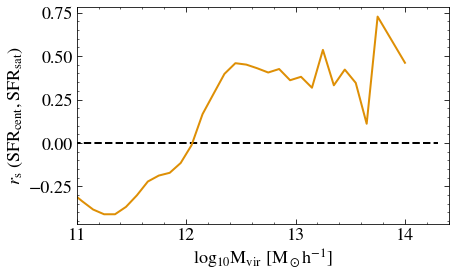

In [30]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_list, color=color_list[2])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [211]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.3])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists1 =[]
for itype in range(1):
    coef_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        if np.sum(mask) > 0:
            percentiles = np.percentile(sfr_types[itype][mask], 99)
            median = np.median(sfr_types[itype][mask])
            diff = percentiles-median
            low_lim = median-diff
            mask = mask & (sfr_types[itype] > low_lim)
        coef = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])[0]
        
        
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
    coef_lists1.append(coef_list)

(11.0, 14.4)

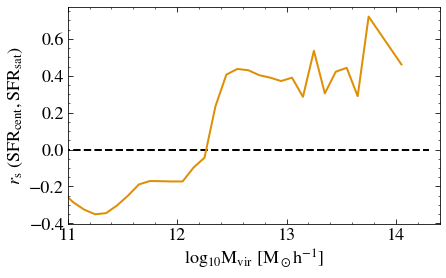

In [212]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_lists1[0], color=color_list[2])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [36]:
percentiles = np.nanpercentile(cent_cprox, 75)
print(percentiles)

3.0675876214771782


In [43]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2


coef_list = []
perr_list = []
for i, m in enumerate(mbins[:-1]):
    
    mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) 
    percentile = np.nanpercentile(cent_cprox[mask], 75)
    mask = mask & (cent_cprox > percentile)
    # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
    # frac_list.append(frac)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    coef = coef1[0]
    perr = coef1[1]
    if np.sum(mask) < 5:
        coef = np.nan
        #print(mcent)
    coef_list.append(coef)
    perr_list.append(perr)

(11.0, 14.4)

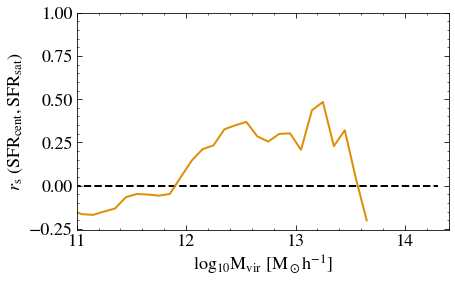

In [44]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")

plt.plot(mbin_cents, coef_list, color=color_list[2])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")

In [202]:
logM = 12.6
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM)

In [203]:
percentiles_list = [0, 25, 50, 75, 100]

In [204]:
property1 = cent_cprox

In [205]:
percentiles = np.nanpercentile(property1[mask_mass], percentiles_list)

In [206]:
print(percentiles)

[7.54655253e-01 1.53695149e+00 2.25738910e+00 4.31245452e+00
 8.60219602e+03]


SpearmanrResult(correlation=0.3597107062882043, pvalue=5.863089696344396e-09)
SpearmanrResult(correlation=0.515077942696737, pvalue=3.3157865355527312e-18)
SpearmanrResult(correlation=0.36421826787363637, pvalue=3.400088415176396e-09)
SpearmanrResult(correlation=0.2867942348260551, pvalue=4.626283591239604e-06)


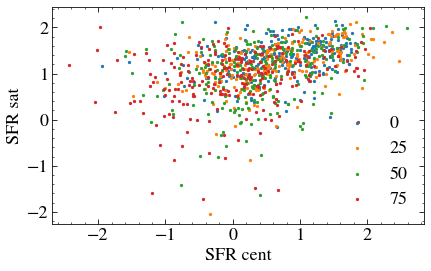

In [207]:
for ip, percentile in enumerate(percentiles_list[:-1]):
    mask = mask_mass & (group_sfrs > -5) & (np.isnan(property1) == False) & (property1 > percentiles[ip]) & (property1 < percentiles[ip+1])
    plt.scatter(cent_sfrs[mask],sum_sfrs[mask], s=5, label=percentile)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    print(coef1)
plt.xlabel("SFR cent")
plt.ylabel("SFR sat")
plt.legend()

In [ ]:
High sat SFR and low cent SFR is lowest concentration bin

In [ ]:
More negative correlation in lower concentration bin

In [146]:
property1 = nsub
percentiles = np.nanpercentile(property1[mask_mass], percentiles_list)

SpearmanrResult(correlation=-0.23611254617394994, pvalue=2.038560517285918e-44)
SpearmanrResult(correlation=nan, pvalue=nan)
SpearmanrResult(correlation=-0.34301434015261495, pvalue=3.4618919136078873e-97)
SpearmanrResult(correlation=-0.1834572168724211, pvalue=7.563064128508743e-35)


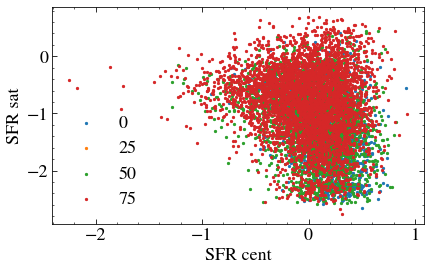

In [147]:
for ip, percentile in enumerate(percentiles_list[:-1]):
    mask = mask_mass & (group_sfrs > -5) & (np.isnan(property1) == False) & (property1 > percentiles[ip]) & (property1 < percentiles[ip+1])
    plt.scatter(cent_sfrs[mask],sum_sfrs[mask], s=5, label=percentile)
    coef1 = stats.spearmanr(cent_sfrs[mask],sum_sfrs[mask])
    print(coef1)
plt.xlabel("SFR cent")
plt.ylabel("SFR sat")
plt.legend()

In [137]:
nsub = halos["GroupNsubs"]

In [191]:
logM = 11.3
dlogM=0.1
mask_mass = (mvir > logM) & (mvir < logM+dlogM) #& (group_sfrs > -5)
nsub1 = nsub[mask_mass]

SpearmanrResult(correlation=0.5364382435511392, pvalue=0.0)


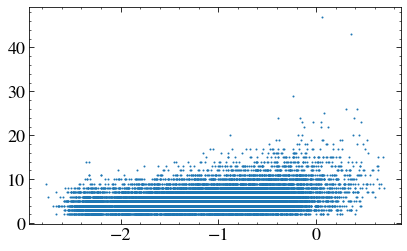

In [155]:
plt.scatter(sum_sfrs[mask_mass], nsub[mask_mass], s=1)
coef1 = stats.spearmanr(sum_sfrs[mask_mass], nsub[mask_mass]-1)
print(coef1)

In [156]:
stats.spearmanr(sum_sat_mass[mask_mass], nsub[mask_mass]-1)

SpearmanrResult(correlation=0.7928302672654063, pvalue=0.0)

In [192]:
testids = np.argwhere((cent_sfrs < 0) & mask_mass)

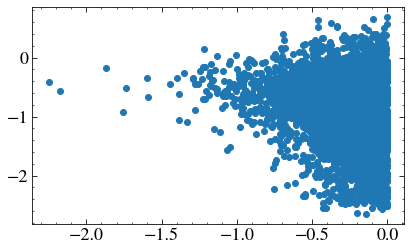

In [193]:
plt.scatter(cent_sfrs[testids], sum_sfrs[testids])

In [194]:
testids

array([[ 31336],
       [ 35571],
       [ 36073],
       ...,
       [150676],
       [150730],
       [150962]])

Text(0.1, 0.85, '$r_\\mathrm{s} = -0.29$')

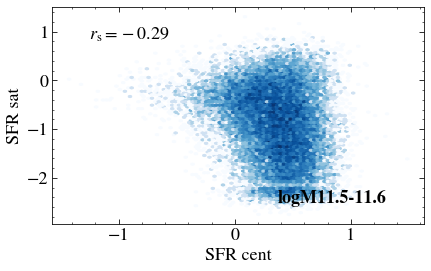

In [178]:
m = 11.5
dlogM=0.1
mask = (mvir > m - dlogM) & (mvir < m + dlogM) & (group_sfrs > -5) 
for itype in range(2,3):
    x = cent_sfrs[mask]
    y = sum_sfrs[mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"SFR sat")
plt.xlabel(r"SFR cent")
hb = plt.hexbin(x, y, gridsize=100, cmap='Blues', bins="log",mincnt=1)

logM_name = f"logM{m}-{np.round(m+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")